In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("xhlulu/leafsnap-dataset")

print("Path to dataset files:", path)

100%|██████████| 840M/840M [00:09<00:00, 96.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1


In [2]:
ls /root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1/leafsnap-dataset/dataset/images

field/  lab/


In [3]:
rm -rf /root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1/leafsnap-dataset/dataset/images/lab/ulmus_procera

In [4]:
rm -rf /root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1/leafsnap-dataset/dataset/images/images_merged

In [5]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import *
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import os
import cv2


In [6]:
field_ds = keras.utils.image_dataset_from_directory(
    directory="/root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1/leafsnap-dataset/dataset/images/field",
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
)
lab_ds = keras.utils.image_dataset_from_directory(
    directory="/root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1/leafsnap-dataset/dataset/images/lab",
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
)

Found 7719 files belonging to 184 classes.
Found 23027 files belonging to 184 classes.


In [7]:
field_classes = set(field_ds.class_names)
lab_classes = set(lab_ds.class_names)

print(lab_classes - field_classes)
print(field_classes - lab_classes)


set()
set()


In [8]:
import os
import shutil

# Define directory paths
field_dir = "/root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1/leafsnap-dataset/dataset/images/field"
lab_dir   = "/root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1/leafsnap-dataset/dataset/images/lab"
target_dir = "/root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1/leafsnap-dataset/dataset/images/images_merged"

# Ensure target directory exists
os.makedirs(target_dir, exist_ok=True)

def merge_folders(source_dir, target_dir, prefix=""):
    """Copies all files from subdirectories in source_dir into target_dir."""
    for class_folder in os.listdir(source_dir):
        source_class_path = os.path.join(source_dir, class_folder)

        # Process only class directories
        if os.path.isdir(source_class_path):
            target_class_path = os.path.join(target_dir, class_folder)
            os.makedirs(target_class_path, exist_ok=True)

            for file_name in os.listdir(source_class_path):
                src_file_path = os.path.join(source_class_path, file_name)

                # Check if it's a valid image file
                if os.path.isfile(src_file_path) and file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    # Add prefix if filename collision might occur
                    new_filename = f"{prefix}_{file_name}" if prefix else file_name
                    dest_file_path = os.path.join(target_class_path, new_filename)

                    # Copy image file
                    shutil.copy2(src_file_path, dest_file_path)

print("Merging 'field' images into target directory...")
merge_folders(field_dir, target_dir, prefix="field")

print("Merging 'lab' images into target directory...")
merge_folders(lab_dir, target_dir, prefix="lab")

print(f"Merge complete! Merged dataset saved at:\n{target_dir}")

Merging 'field' images into target directory...
Merging 'lab' images into target directory...
Merge complete! Merged dataset saved at:
/root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1/leafsnap-dataset/dataset/images/images_merged


In [9]:
dataset_dir = "/root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1/leafsnap-dataset/dataset/images/images_merged"
SEED = 42

# Training set (80%)
train_ds = keras.utils.image_dataset_from_directory(
    directory=dataset_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset='training',
    seed=SEED
)

# Testing / Validation set (20%)
val_ds = keras.utils.image_dataset_from_directory(
    directory=dataset_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset='validation',
    seed=SEED  # The seed MUST be identical to train_ds
)

# Extract class names before training
class_names = train_ds.class_names

Found 30746 files belonging to 184 classes.
Using 24597 files for training.
Found 30746 files belonging to 184 classes.
Using 6149 files for validation.


In [10]:
for (image, label) in train_ds:
    print("Label:", label[0].numpy())
    print("Max pixel value:", tf.reduce_max(image[0]).numpy())
    print("Min pixel value:", tf.reduce_min(image[0]).numpy())
    break

Label: 178
Max pixel value: 255.0
Min pixel value: 24.543457


In [11]:
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

In [12]:
model = Sequential()

model.add(Input(shape=(256,256,3)))
model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), padding='same' ))

model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), padding='same' ))

model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), padding='same' ))

model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), padding='same' ))

model.add(Conv2D(512, kernel_size=(3,3), padding='same', activation='relu' ))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2), padding='same' ))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(184 , activation='softmax'))

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 512)    │         2,04

 Total params: 19,618,456 (74.84 MB)

 Trainable params: 19,616,472 (74.83 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [13]:
model.compile(
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    optimizer=Adam(learning_rate=0.001),
)

In [16]:
history = model.fit(train_ds, epochs=20, validation_data=val_ds)

Epoch 1/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 347s 451ms/step - accuracy: 0.3824 - loss: 2.0992 - val_accuracy: 0.4537 - val_loss: 1.8375
Epoch 2/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 348s 453ms/step - accuracy: 0.4192 - loss: 1.9574 - val_accuracy: 0.4744 - val_loss: 1.7933
Epoch 3/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 349s 453ms/step - accuracy: 0.4523 - loss: 1.8233 - val_accuracy: 0.4755 - val_loss: 1.8659
Epoch 4/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 348s 452ms/step - accuracy: 0.4862 - loss: 1.6815 - val_accuracy: 0.5137 - val_loss: 1.6758
Epoch 5/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 348s 453ms/step - accuracy: 0.5153 - loss: 1.5703 - val_accuracy: 0.5811 - val_loss: 1.3447
Epoch 6/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 348s 453ms/step - accuracy: 0.5423 - loss: 1.4560 - val_accuracy: 0.5977 - val_loss: 1.3562
Epoch 7/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 348s 452ms/step - accuracy: 0.5728 - loss: 1.3436 - val_accuracy: 0.6290 - val_loss: 1.2716
Epoch 8/20
769/769 ━━━━━━━━━━━━━━━━━━━━ 348s 452ms/step - accuracy: 0.6056 -

In [17]:
model.save("leaf_classification.keras")


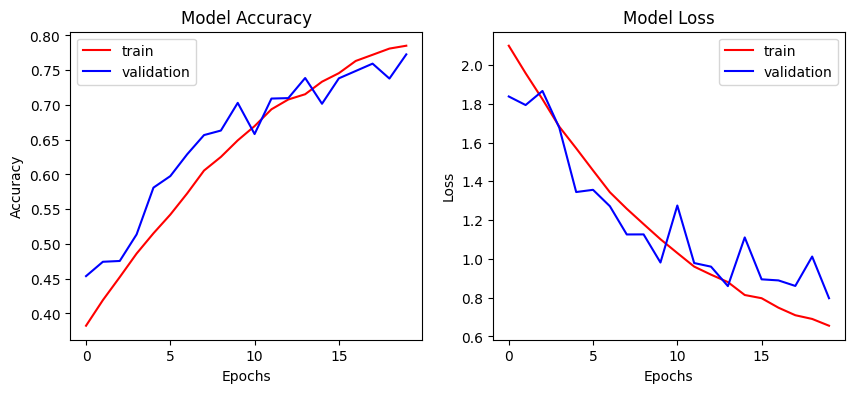

In [18]:
# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
train_dir = '/content/images_merged/images_merged'
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

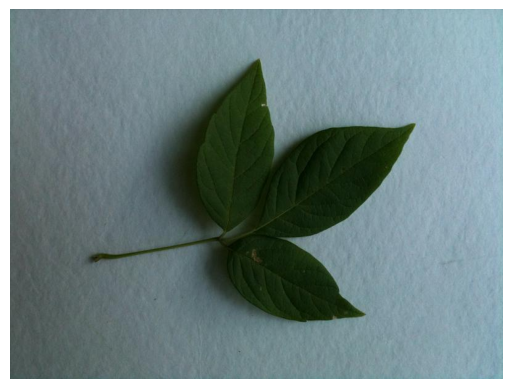

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

--- Top 10 Predictions ---
 1. acer_negundo              | Confidence:  41.44% (Index: 5)
 2. carya_glabra              | Confidence:   7.75% (Index: 32)
 3. quercus_falcata           | Confidence:   6.96% (Index: 144)
 4. quercus_imbricaria        | Confidence:   6.05% (Index: 145)
 5. quercus_michauxii         | Confidence:   5.86% (Index: 148)
 6. acer_platanoides          | Confidence:   5.85% (Index: 8)
 7. carya_tomentosa           | Confidence:   5.01% (Index: 34)
 8. quercus_bicolor           | Confidence:   3.42% (Index: 141)
 9. liquidambar_styraciflua   | Confidence:   2.00% (Index: 78)
10. acer_saccharum            | Confidence:   1.87% (Index: 12)


In [23]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

image_path = '/content/field_13001151163898.jpg'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)
    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels
    test_input = test_input / 255.0

    # Get class names from the directory subfolders directly
    train_dir = '/root/.cache/kagglehub/datasets/xhlulu/leafsnap-dataset/versions/1/leafsnap-dataset/dataset/images/images_merged'
    class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

    # Predict raw output probabilities across all classes (softmax)
    raw_prediction = model.predict(test_input)[0]  # Flatten to 1D array of probabilities

    # Get indices of the top 10 predictions sorted in descending order
    top_10_indices = np.argsort(raw_prediction)[::-1][:10]

    print("\n--- Top 10 Predictions ---")
    for rank, idx in enumerate(top_10_indices, start=1):
        class_name = class_names[idx]
        confidence = float(raw_prediction[idx]) * 100
        print(f"{rank:2d}. {class_name:<25} | Confidence: {confidence:6.2f}% (Index: {idx})")

else:
    print(f"Image not found at {image_path}. Please check your path.")